In [12]:
import torch

In [13]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import cv2
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, balanced_accuracy_score
from sklearn.model_selection import GroupKFold
from sklearn.utils.class_weight import compute_class_weight
from scipy.ndimage import shift
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. KONFIGURASI (UPDATED FOR 9 REGIONS)
# ==========================================
DATA_DIR = "output_flow_regions_npy_9ch_float32_cleaned"
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
EPOCHS = 200
# Update Dimensi Input
INPUT_SHAPE = (9, 64, 64, 1) 
NUM_REGIONS = 9 

PROJECTION_DIM = 32
NUM_HEADS = 2
TRANSFORMER_LAYERS = 2

# Mapping Label (Sesuaikan kebutuhan)
LABEL_MAPPING = {
    'happy': 'Positive',
    'disgust': 'Negative',
    'anger': 'Negative',
    'fear': 'Negative',
    'sad': 'Negative',
}


Using device: cuda


In [14]:
import random


def set_seed(seed=42):
    """Mengunci semua seed agar eksperimen bisa direproduksi."""
    # Kunci seed untuk NumPy (digunakan di fungsi augmentasi Anda)
    np.random.seed(seed)
    
    # Kunci seed untuk Python random (jika suatu saat digunakan)
    random.seed(seed)
    
    # Kunci seed untuk PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Jika pakai multi-GPU
    
    # Pastikan operasi PyTorch juga deterministik (opsional tapi disarankan)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Panggil fungsi ini sebelum memuat data atau memanggil augmentasi
set_seed(42)

In [15]:
# ==========================================
# 2. FUNGSI AUGMENTASI (UPDATED 9 REGIONS)
# ==========================================
def augment_mirror_regions(data_9ch):
    """
    Input: (Batch, N_Regions, 64, 64, 1)
    Output: Flip Horizontal + Swap Region Kanan/Kiri
    """
    # 1. Flip gambar secara horizontal (axis 3 adalah Width)
    data_flipped = np.flip(data_9ch, axis=3).copy()
    
    # 2. Re-order regions (Swap Kanan <-> Kiri)
    new_order = [0, 2, 1, 3, 5, 4, 6, 8, 7]
    
    # [DIUBAH] Tambahkan titik dua ":" di awal untuk melewati dimensi Batch
    # Sehingga new_order diaplikasikan pada dimensi ke-2 (N_Regions)
    data_augmented = data_flipped[:, new_order, :, :, :]
    
    return data_augmented

def augment_noise(data_9ch):
    """Menambahkan sedikit random noise"""
    noise = np.random.normal(0, 0.02, data_9ch.shape)
    return (data_9ch + noise).astype(np.float32)

def augment_magnitude_scaling(data_9ch, min_scale=0.8, max_scale=1.2):
    """Mengubah intensitas gerakan (flow/strain)."""
    scale = np.random.uniform(min_scale, max_scale)
    return (data_9ch * scale).astype(np.float32)

def augment_random_erasing(data_9ch, p=0.5, sl=0.02, sh=0.1, r1=0.3):
    """Randomly erases a rectangular area in each region independently."""
    img_aug = data_9ch.copy()
    for i in range(data_9ch.shape[0]):           # loop Batch
        for j in range(data_9ch.shape[1]):       # loop Regions
            if np.random.rand() > p:
                continue
            H, W = data_9ch.shape[2], data_9ch.shape[3]  # 64, 64
            area = H * W
            target_area = np.random.uniform(sl, sh) * area
            aspect_ratio = np.random.uniform(r1, 1/r1)
            h = int(round(np.sqrt(target_area * aspect_ratio)))
            w = int(round(np.sqrt(target_area / aspect_ratio)))
            if w < W and h < H:
                x1 = np.random.randint(0, H - h)
                y1 = np.random.randint(0, W - w)
                img_aug[i, j, x1:x1+h, y1:y1+w, :] = 0
    return img_aug


def augment_micro_translation(data_9ch, max_shift=2):
    """Menggeser patch wajah 1-2 piksel untuk mensimulasikan error cropping."""
    img_aug = np.zeros_like(data_9ch)
    
    for i in range(data_9ch.shape[0]):
        # Geser acak antara -max_shift hingga max_shift untuk axis X (Tinggi) dan Y (Lebar)
        shift_x = np.random.randint(-max_shift, max_shift + 1)
        shift_y = np.random.randint(-max_shift, max_shift + 1)
        
        # Perbaikan: Berikan 4 nilai shift sesuai shape (9, 64, 64, 1)
        # Urutannya: (Shift_Region, Shift_Height, Shift_Width, Shift_Channel)
        # Kita biarkan Region dan Channel di angka 0 agar tidak bergeser.
        img_aug[i] = shift(data_9ch[i], shift=(0, shift_x, shift_y, 0), mode='nearest')
        
    return img_aug.astype(np.float32)

def augment_gaussian_blur(data_9ch, max_kernel=3):
    """Menambahkan efek blur ringan secara acak pada setiap region."""
    img_aug = np.zeros_like(data_9ch)
    
    # Kadang kernel 1 (tidak ada blur), kadang 3 (blur ringan)
    kernel_size = np.random.choice([1, 3]) 
    if kernel_size == 1:
        return data_9ch.copy() # Skip blur
        
    # data_9ch memiliki shape (Batch, 9, 64, 64, 1)
    for i in range(data_9ch.shape[0]):           # 1. Loop per sampel data (Batch)
        for j in range(data_9ch.shape[1]):       # 2. Loop per region wajah (9 Regions)
            
            # Ambil 1 area spesifik. 
            # Slice [:, :, 0] membuang dimensi channel agar shape menjadi (64, 64) murni
            patch_2d = data_9ch[i, j, :, :, 0] 
            
            # Aplikasikan blur pada array 2D
            blurred = cv2.GaussianBlur(patch_2d, (kernel_size, kernel_size), 0)
            
            # Kembalikan dimensi channel menjadi (64, 64, 1) dan masukkan ke array output
            img_aug[i, j] = np.expand_dims(blurred, axis=-1)
            
    return img_aug.astype(np.float32)

In [16]:
# ==========================================
# 3. DATA LOADER (PYTORCH)
# ==========================================
class MERDataset(Dataset):
    def __init__(self, X, y, file_paths=None):
        # Convert X from (Batch, N_Regions, 64, 64, 1) -> (Batch, N_Regions, 1, 64, 64)
        # In PyTorch, 2D Conv expects (Channels, H, W) where Channel=1 here.
        self.X = torch.tensor(X).permute(0, 1, 4, 2, 3).float()
        self.y = torch.tensor(y).long()
        self.file_paths = file_paths

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        if self.file_paths is not None:
            return self.X[idx], self.y[idx], self.file_paths[idx]
        return self.X[idx], self.y[idx]

def load_data(data_dir, mapping):
    X, y, groups, file_paths = [], [], [], []
    if not os.path.exists(data_dir):
        raise ValueError(f"Folder dataset tidak ditemukan: {data_dir}")

    available_folders = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    available_folders.sort()
    
    print("--- Proses Loading Data (9 Regions) ---")
    
    for folder_name in available_folders:
        if folder_name not in mapping: continue
        target_label = mapping[folder_name]
        print(f"[LOAD] Class '{folder_name}' -> Label '{target_label}'")
        
        folder_path = os.path.join(data_dir, folder_name)
        files = glob.glob(os.path.join(folder_path, "*.npy"))
        
        for f in files:
            data = np.load(f)
            if data.shape != INPUT_SHAPE:
                print(f"Warning: File {os.path.basename(f)} shape {data.shape} tidak sesuai {INPUT_SHAPE}. Skip.")
                continue

            filename = os.path.basename(f)
            subject_id = filename.split('_')[0] 
            
            X.append(data)
            y.append(target_label)
            groups.append(subject_id)
            file_paths.append(f)

    X = np.array(X, dtype=np.float32)
    for i in range(len(X)):
        sample = X[i]
        s_min = sample.min()
        s_max = sample.max()
        if s_max - s_min > 1e-8:  # hindari division by zero
            X[i] = (sample - s_min) / (s_max - s_min)
        else:
            X[i] = np.zeros_like(sample)
    y = np.array(y)
    groups = np.array(groups)
    file_paths = np.array(file_paths)
    
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    print(f"\nTotal Data Loaded: {len(X)}")
    print(f"Total Subject: {len(np.unique(groups))}")
    print(f"Classes: {le.classes_}")
    
    return X, y_encoded, groups, file_paths, le.classes_

def apply_augmentation(X_batch, y_batch):
    """
    Menerima batch data train dan melakukan augmentasi ke SEMUA KELAS.
    """
    X_aug = [X_batch]
    y_aug = [y_batch]
    
    if len(X_batch) > 0:
        # 1. Mirror (Flip Horizontal + Swap ROI Kiri/Kanan)
        data_mirror = augment_mirror_regions(X_batch)
        X_aug.append(data_mirror)
        y_aug.append(y_batch)
        
        # 2. Scaling (Intensity Variation)
        data_scale = augment_magnitude_scaling(X_batch, min_scale=0.9, max_scale=1.1)
        X_aug.append(data_scale)
        y_aug.append(y_batch)
        
        # 3. Random Erasing (Occlusion)
        X_aug.append(augment_random_erasing(X_batch, p=1.0)) 
        y_aug.append(y_batch)

        # 4. Gaussian Noise
        X_aug.append(augment_noise(X_batch))
        y_aug.append(y_batch)

        data_mirror_noise = augment_noise(data_mirror)
        X_aug.append(data_mirror_noise)
        y_aug.append(y_batch)

      

        # X_aug.append(augment_micro_translation(X_batch))
        # y_aug.append(y_batch)

    # Gabungkan semua list array menjadi satu array besar
    return np.concatenate(X_aug, axis=0), np.concatenate(y_aug, axis=0)

In [17]:
# ==========================================
# 4. MODEL ARCHITECTURE (PYTORCH) - UPDATED
# ==========================================

class MobileNetBackbone(nn.Module):
    def __init__(self, in_channels=1, proj_dim=64):
        super().__init__()
        self.backbone = models.mobilenet_v3_small(
            weights=models.MobileNet_V3_Small_Weights.DEFAULT
        )
        
        # Ganti first conv DULU
        original_conv = self.backbone.features[0][0]
        self.backbone.features[0][0] = nn.Conv2d(
            in_channels, 
            original_conv.out_channels, 
            kernel_size=original_conv.kernel_size, 
            stride=original_conv.stride, 
            padding=original_conv.padding, 
            bias=original_conv.bias is not None
        )
        
        # Freeze layer 1-8 (SKIP layer 0 yang baru diganti)
        for param in self.backbone.features[1:9].parameters():
            param.requires_grad = False
        
        # Classifier head
        in_features = self.backbone.classifier[3].in_features
        self.backbone.classifier[3] = nn.Linear(in_features, proj_dim)

        
    def forward(self, x):
        # x: (Batch*Region, 1, 64, 64)
        # MobileNet akan langsung mengembalikan output berukuran (Batch*Region, proj_dim)
        return self.backbone(x)

class PositionalEmbedding(nn.Module):
    """Inject order positional info so the model knows which feature is left eye vs mouth"""
    def __init__(self, num_regions, proj_dim):
        super().__init__()
        self.pos_emb = nn.Parameter(torch.randn(1, num_regions, proj_dim) * 0.02)
        
    def forward(self, x):
        # x is (B, num_regions, proj_dim)
        return x + self.pos_emb

class CNNTransformerModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        
        # Gunakan MobileNetBackbone sebagai pengganti CNNBackbone kustom
        self.cnn = MobileNetBackbone(in_channels=1, proj_dim=PROJECTION_DIM)
        self.pos_emb = PositionalEmbedding(NUM_REGIONS, PROJECTION_DIM)
        
        # Transformer Layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=PROJECTION_DIM, 
            nhead=NUM_HEADS, 
            dim_feedforward=PROJECTION_DIM * 2, 
            dropout=0.1, 
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=TRANSFORMER_LAYERS)
        
        # Classifier Head
        self.classifier_dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(PROJECTION_DIM, 64)
        self.fc2 = nn.Linear(64, num_classes)
        
    def forward(self, x):
        # x: (B, 9, 1, 64, 64)
        B, N, C, H, W = x.shape
        
        # Equivalent to TimeDistributed:
        x = x.view(B * N, C, H, W)
        features = self.cnn(x)
        features = features.view(B, N, -1) # Reshape back to sequence (B, 9, 64)
        
        # Transformer Input
        x = self.pos_emb(features)
        x = self.transformer(x)
        
        # Global Max Pooling 1D
        x = x.mean(dim=1)
        
        # Classifier
        x = self.classifier_dropout(x)
        x = F.relu(self.fc1(x))
        out = self.fc2(x) # Logits (Raw scores)
        return out

In [18]:
# ==========================================
# 5. TRAINING LOOP (GROUP K-FOLD)
# ==========================================
# 1. Load Data
X, y, groups, _, class_names = load_data(DATA_DIR, LABEL_MAPPING)
num_classes = len(class_names)
positive_class_index = np.where(class_names == 'Positive')[0][0]
negative_class_index = np.where(class_names == 'Negative')[0][0]

# --- INISIALISASI GROUP K-FOLD ---
N_SPLITS = 10
gkf = GroupKFold(n_splits=N_SPLITS)

y_true_all, y_pred_all = [], []
fold_no = 1
unique_groups = np.unique(groups)
fold_epochs = []

print(f"\n{'='*20} MEMULAI GROUP K-FOLD CROSS-VALIDATION (K={N_SPLITS}) {'='*20}\n")
print(f"Total Subjek dalam Dataset: {len(unique_groups)}")

for train_index, val_index in gkf.split(X, y, groups=groups):
    # Ambil array subjek unik yang berada di dalam fold validasi ini
    current_subjects = np.unique(groups[val_index])
    print(f"Processing Fold {fold_no}/{N_SPLITS} | Subjects Test: {current_subjects}")
    
    # Membagi data berdasarkan index fold
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]
    
    print(f"  Data Train Awal: {len(X_train)}")
    X_train_aug, y_train_aug = apply_augmentation(X_train, y_train)
    print(f"  Data Train Augm: {len(X_train_aug)}")

    # Shuffle training set manually before datasets
    perm = np.random.permutation(len(X_train_aug))
    X_train_aug = X_train_aug[perm]
    y_train_aug = y_train_aug[perm]

    # Create DataLoaders
    train_dataset = MERDataset(X_train_aug, y_train_aug)
    val_dataset = MERDataset(X_val, y_val)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    # Setup Weighted Loss
    classes = np.unique(y_train_aug)
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=y_train_aug
    )

    # Convert ke tensor sesuai urutan class index
    weight_tensor = torch.zeros(num_classes)

    for i, cls in enumerate(classes):
        weight_tensor[cls] = class_weights[i]

    weight_tensor = weight_tensor.to(device)

    criterion = nn.CrossEntropyLoss(weight=weight_tensor)
        
    # Initialize Model
    model = CNNTransformerModel(num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Early Stopping setups
    best_val_loss = float('inf')
    # Penyesuaian patience: dinaikkan karena loss validasi akan lebih smooth/stabil 
    patience = 40 
    patience_counter = 0
    best_model_state = None
    best_epoch_fold = 0
    
    # EPOCH LOOP
    for epoch in range(EPOCHS):
        # --- Training ---
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
        train_loss /= train_total
        train_acc = train_correct / train_total
        
        # --- Validation ---
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
        val_loss /= val_total if val_total > 0 else 1
        val_acc = (val_correct / val_total) if val_total > 0 else 0
        
        # Print progress conditionally to avoid spamming
        if (epoch+1) == 1 or (epoch+1) % 10 == 0 or (epoch+1) == EPOCHS:
            print(f"  Epoch [{epoch+1}/{EPOCHS}] Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
            
        # Early Stopping Check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = {k: v.cpu() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            best_epoch_fold = epoch + 1
            print(f"  Early stopping triggered at epoch {epoch+1}")
            break

    fold_epochs.append(best_epoch_fold)  
    # Restore best weights and Extract FINAL Validation Predictions
    if best_model_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
        
    model.eval()
    val_preds = []
    val_trues = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            val_preds.extend(predicted.cpu().numpy())
            val_trues.extend(labels.numpy())
            
    y_true_all.extend(val_trues)
    y_pred_all.extend(val_preds)
    
    # Jika test validation batch kosong, tangani gracefully
    acc_fold = accuracy_score(val_trues, val_preds) if len(val_trues) > 0 else 0
    print(f"--> Accuracy Fold {fold_no}: {acc_fold:.4f}\n")
    fold_no += 1

--- Proses Loading Data (9 Regions) ---
[LOAD] Class 'anger' -> Label 'Negative'
[LOAD] Class 'disgust' -> Label 'Negative'
[LOAD] Class 'fear' -> Label 'Negative'
[LOAD] Class 'happy' -> Label 'Positive'
[LOAD] Class 'sad' -> Label 'Negative'

Total Data Loaded: 111
Total Subject: 33
Classes: ['Negative' 'Positive']

==================== MEMULAI GROUP K-FOLD CROSS-VALIDATION (K=10) ====================

Total Subjek dalam Dataset: 33
Processing Fold 1/10 | Subjects Test: ['spNO.163' 'spNO.210' 'spNO.214' 'spNO.40']
  Data Train Awal: 99
  Data Train Augm: 594


d:\anaconda3\envs\py310\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  Epoch [1/200] Train Loss: 0.6975 Acc: 0.5168 | Val Loss: 0.6959 Acc: 0.5000
  Epoch [10/200] Train Loss: 0.2819 Acc: 0.8990 | Val Loss: 1.4108 Acc: 0.4167
  Epoch [20/200] Train Loss: 0.1222 Acc: 0.9512 | Val Loss: 1.8220 Acc: 0.5000
  Epoch [30/200] Train Loss: 0.0844 Acc: 0.9630 | Val Loss: 2.6397 Acc: 0.4167
  Epoch [40/200] Train Loss: 0.0484 Acc: 0.9798 | Val Loss: 2.6367 Acc: 0.4167
  Early stopping triggered at epoch 46
--> Accuracy Fold 1: 0.6667

Processing Fold 2/10 | Subjects Test: ['spNO.183' 'spNO.212' 'spNO.8']
  Data Train Awal: 100
  Data Train Augm: 600


d:\anaconda3\envs\py310\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  Epoch [1/200] Train Loss: 0.6941 Acc: 0.5217 | Val Loss: 0.7031 Acc: 0.4545
  Epoch [10/200] Train Loss: 0.2955 Acc: 0.9017 | Val Loss: 1.2736 Acc: 0.5455
  Epoch [20/200] Train Loss: 0.1098 Acc: 0.9567 | Val Loss: 1.5451 Acc: 0.5455
  Epoch [30/200] Train Loss: 0.0733 Acc: 0.9700 | Val Loss: 1.4311 Acc: 0.7273
  Epoch [40/200] Train Loss: 0.0630 Acc: 0.9783 | Val Loss: 1.8033 Acc: 0.5455
  Early stopping triggered at epoch 46
--> Accuracy Fold 2: 0.6364

Processing Fold 3/10 | Subjects Test: ['spNO.172' 'spNO.201' 'spNO.42']
  Data Train Awal: 100
  Data Train Augm: 600


...

  Epoch [1/200] Train Loss: 0.7092 Acc: 0.5217 | Val Loss: 0.7211 Acc: 0.4545
  Epoch [10/200] Train Loss: 0.3032 Acc: 0.8783 | Val Loss: 1.7438 Acc: 0.3636
  Epoch [20/200] Train Loss: 0.1526 Acc: 0.9417 | Val Loss: 1.7554 Acc: 0.5455
  Epoch [30/200] Train Loss: 0.0769 Acc: 0.9717 | Val Loss: 1.9641 Acc: 0.3636
  Epoch [40/200] Train Loss: 0.0693 Acc: 0.9733 | Val Loss: 2.7481 Acc: 0.3636
  Early stopping triggered at epoch 42
--> Accuracy Fold 8: 0.4545

Processing Fold 9/10 | Subjects Test: ['spNO.10' 'spNO.204' 'spNO.209']
  Data Train Awal: 100
  Data Train Augm: 600


d:\anaconda3\envs\py310\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  Epoch [1/200] Train Loss: 0.7015 Acc: 0.5000 | Val Loss: 0.6593 Acc: 0.7273
  Epoch [10/200] Train Loss: 0.3417 Acc: 0.8633 | Val Loss: 1.2077 Acc: 0.3636
  Epoch [20/200] Train Loss: 0.1379 Acc: 0.9583 | Val Loss: 1.9851 Acc: 0.4545
  Epoch [30/200] Train Loss: 0.0703 Acc: 0.9783 | Val Loss: 2.0908 Acc: 0.4545
  Epoch [40/200] Train Loss: 0.0474 Acc: 0.9867 | Val Loss: 1.8299 Acc: 0.7273
  Early stopping triggered at epoch 41
--> Accuracy Fold 9: 0.7273

Processing Fold 10/10 | Subjects Test: ['spNO.145' 'spNO.150' 'spNO.174' 'spNO.178']
  Data Train Awal: 100
  Data Train Augm: 600


d:\anaconda3\envs\py310\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  Epoch [1/200] Train Loss: 0.7044 Acc: 0.5267 | Val Loss: 0.6734 Acc: 0.5455
  Epoch [10/200] Train Loss: 0.3604 Acc: 0.8483 | Val Loss: 1.1594 Acc: 0.5455
  Epoch [20/200] Train Loss: 0.1380 Acc: 0.9433 | Val Loss: 1.5169 Acc: 0.4545
  Epoch [30/200] Train Loss: 0.0766 Acc: 0.9733 | Val Loss: 2.0426 Acc: 0.5455
  Epoch [40/200] Train Loss: 0.0732 Acc: 0.9733 | Val Loss: 1.6133 Acc: 0.6364
  Early stopping triggered at epoch 49
--> Accuracy Fold 10: 0.7273




HASIL AKHIR GROUP K-FOLD
Accuracy (Overall) : 0.7117
UAR (Balanced Acc) : 0.7077
UF1 (Macro F1)     : 0.7077

Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.74      0.74        62
    Positive       0.67      0.67      0.67        49

    accuracy                           0.71       111
   macro avg       0.71      0.71      0.71       111
weighted avg       0.71      0.71      0.71       111



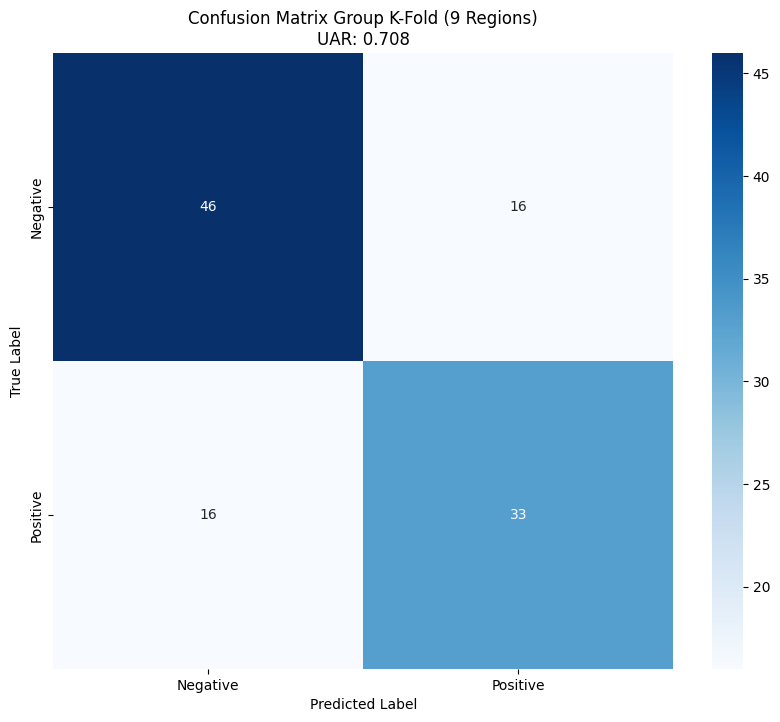

In [19]:
# ==========================================
# 6. EVALUASI AKHIR
# ==========================================
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

acc = accuracy_score(y_true_all, y_pred_all)
uar = balanced_accuracy_score(y_true_all, y_pred_all)
uf1 = f1_score(y_true_all, y_pred_all, average='macro')

print("\n" + "="*40)
print(f"HASIL AKHIR GROUP K-FOLD")
print("="*40)
print(f"Accuracy (Overall) : {acc:.4f}")
print(f"UAR (Balanced Acc) : {uar:.4f}")
print(f"UF1 (Macro F1)     : {uf1:.4f}")
print("="*40 + "\n")

print("Classification Report:")
print(classification_report(y_true_all, y_pred_all, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix Group K-Fold (9 Regions)\nUAR: {uar:.3f}')
plt.show()


In [20]:
# ==========================================
# 7. TRAIN FINAL MODEL ON SELECTED DATA & SAVE
# ==========================================
print("\n" + "="*40)
print("MEMULAI TRAINING MODEL FINAL")
print("="*40)

# ---------------------------------------------------------
# TAMBAHAN: List subjek yang dialokasikan sebagai Test Set
# Kosongkan list ini [] jika ingin melatih menggunakan 100% data
# ---------------------------------------------------------
test_subjects = [''] # Contoh: ['spNO.1', 'spNO.10']

if len(test_subjects) > 0:
    print(f"Subjek berikut dijadikan test set dan TIDAK ikut ditraining: {test_subjects}")
    # Cari indeks data yang BUKAN milik subjek di test_subjects
    train_mask = ~np.isin(groups, test_subjects)
    
    X_train_final = X[train_mask]
    y_train_final = y[train_mask]
    
    # (Opsional) Data test bisa diekstrak di sini jika ingin dievaluasi setelah model selesai
    # test_mask = np.isin(groups, test_subjects)
    # X_test_final = X[test_mask]
    # y_test_final = y[test_mask]
else:
    print("List test kosong. Melatih model menggunakan SELURUH DATA (100%).")
    X_train_final = X
    y_train_final = y

print(f"Total data latih murni (sebelum augmentasi): {len(X_train_final)}")

# ---------------------------------------------------------
# Setup Weighted Loss (Dihitung ulang berdasarkan data latih final)
# ---------------------------------------------------------
classes = np.unique(y_train_final)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_final
)

weight_tensor = torch.zeros(num_classes)
for i, cls in enumerate(classes):
    weight_tensor[cls] = class_weights[i]

weight_tensor = weight_tensor.to(device)
criterion = nn.CrossEntropyLoss(weight=weight_tensor)

# ---------------------------------------------------------
# Eksekusi Pelatihan
# ---------------------------------------------------------
# Augmentasi HANYA pada data latih yang sudah difilter
X_all_aug, y_all_aug = apply_augmentation(X_train_final, y_train_final)
print(f"Total data latih setelah augmentasi: {len(X_all_aug)}\n")

# Shuffle
perm = np.random.permutation(len(X_all_aug))
X_all_aug = X_all_aug[perm]
y_all_aug = y_all_aug[perm]

# DataLoader
final_dataset = MERDataset(X_all_aug, y_all_aug)
final_loader = DataLoader(final_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Define Model
final_model = CNNTransformerModel(num_classes).to(device)
optimizer = optim.Adam(final_model.parameters(), lr=LEARNING_RATE)

# Menggunakan rata-rata epoch dari log LOSO
try:
    avg_epochs_float = np.max(fold_epochs)
    FINAL_EPOCHS = int(np.round(avg_epochs_float))
except NameError:
    # Fallback jika fold_epochs tidak ditemukan di memori
    FINAL_EPOCHS = 45 
    
print(f"Model akan dilatih selama {FINAL_EPOCHS} epoch.")

for epoch in range(FINAL_EPOCHS):
    final_model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels in final_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
    train_loss /= train_total
    train_acc = train_correct / train_total
    
    if (epoch+1) == 1 or (epoch+1) % 10 == 0 or (epoch+1) == FINAL_EPOCHS:
        print(f"  Epoch [{epoch+1}/{FINAL_EPOCHS}] Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}")

# Save Model
model_save_path = "final_mer_model_9ch_test.pth"
torch.save({
    'model_state_dict': final_model.state_dict(),
    'class_names': class_names,
    'input_shape': INPUT_SHAPE,
    'num_regions': NUM_REGIONS
}, model_save_path)

print(f"\nModel berhasil disimpan ke: {model_save_path}")
print("Anda dapat meload model ini nantinya menggunakan state_dict untuk prediksi (inference).")


MEMULAI TRAINING MODEL FINAL
Subjek berikut dijadikan test set dan TIDAK ikut ditraining: ['']
Total data latih murni (sebelum augmentasi): 111
Total data latih setelah augmentasi: 666

Model akan dilatih selama 102 epoch.


d:\anaconda3\envs\py310\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  Epoch [1/102] Train Loss: 0.7076 Acc: 0.4775
  Epoch [10/102] Train Loss: 0.3602 Acc: 0.8498
  Epoch [20/102] Train Loss: 0.1504 Acc: 0.9489
  Epoch [30/102] Train Loss: 0.0594 Acc: 0.9790
  Epoch [40/102] Train Loss: 0.0864 Acc: 0.9700
  Epoch [50/102] Train Loss: 0.0579 Acc: 0.9805
  Epoch [60/102] Train Loss: 0.0421 Acc: 0.9850
  Epoch [70/102] Train Loss: 0.0505 Acc: 0.9835
  Epoch [80/102] Train Loss: 0.0240 Acc: 0.9880
  Epoch [90/102] Train Loss: 0.0345 Acc: 0.9865
  Epoch [100/102] Train Loss: 0.0210 Acc: 0.9925
  Epoch [102/102] Train Loss: 0.0095 Acc: 0.9985

Model berhasil disimpan ke: final_mer_model_9ch_test.pth
Anda dapat meload model ini nantinya menggunakan state_dict untuk prediksi (inference).
